# Hands-on session
We will be using this notebook for the hands-on portion of the session. Notebooks allow us to run snippets of code without needing to download/configure software. This session was jointly developed by [Dr Sarah Faber](https://github.com/fabsarah/) and Dr Jack Solomon based on earlier workshops by the incomparable [Dr Anisha Khosla](https://github.com/anishakhosla/rtc_workshop/blob/master/python_july2020/complete_PythonWorkshop2020.ipynb)

Let's begin!

## Nuts & Bolts
**Note: To run (execute) the code cells, press control/command + Enter**

You can do math in the python cells
Types of Operations:

Addition: '+'

Subtraction: '-'

Multiplication: '*'

Division: '/'

Exponents: '**'

In [ ]:
# addition +

4 + 6

In [ ]:

# subtraction -
# multiplication *
# division /

((78-6)*3)/8

# Some general programming anatomy

In [ ]:
# This is a comment! Use this when you want to write notes to humans (the computer will ignore these)
This is not! The computer will pay attention to it.

#Day 1: And now, the data part!
Let's look at some data. The first thing we're going to do is add the 'pandas' package to our environment. Pandas is a common and useful package in python for dealing with tables, matrices, and other common data forms. If you're working locally, you might need to install the package :

In [ ]:
pip install name_of_package_here
#for example: pip install pandas

We already have pandas and nympy, so we can go right to importing it! Whenever you start up an environment, you'll need to add the package(s) you want to use.

(Pandas and numpy are two super useful packages for looking at and analyzing data)

In [ ]:
# import pandas library as pd

import pandas as pd
import numpy as np

#Importing data from a csv file
Often, you'd read a file off of a computer. The code below shows how to do this. If the file is not in the current directory, write the full path name. You can also read in specfic sheets of an excel file using xlrd:

In [ ]:
# function for reading files
pd.read_csv('filename.csv')
pd.read_excel('filename.xlsx')

If you want to get your data out of the python environment and back into a .csv or .xlsx file, you can use the following, remembering to sub in the name of the variable before the .to_csv or .to_excel:

In [ ]:
# function for writing files. Let's pretend we're converting a variable called 'awesome_data':
awesome_data.to_csv('filename.csv')# remember your file extensions!
awesome_data.to_excel('filename.xlsx')

# And now, let's look at some data!
This is a dataset from 2018 on Marvel and DC superhero movies. We have the following data:

*   Title
*   Studio (Marvel or DC)
*   Year of release
*   Tomatometer (Rotten Tomatoes critics' ratings)
*   Popcorn meter (Rotten Tomatoes viewer ratings)
*   Enjoyment (Participant ratings on a 1 (low)-10 (high) Likert scale)
*   Fun (Participant ratings on a 1 (low)-7 (high) Likert scale)
*   Silly (Participant ratings on a 1 (low)-7 (high) Likert scale)
*   NChris (how many Hot* Chrises are in this movie)

*hot as of 2018




In [ ]:
#Read in some data! This works for collab users:

url = 'https://raw.githubusercontent.com/INN-SFU/SummerResearchBootcamp/main/Session_1/FilmDataStart.csv'
 super_data = pd.read_csv(url)
super_data #note: this will print ALL of our data. If you want to see the first few lines only, you can use super_data.head()



In [ ]:
#But if you're on Jupyter Online, use this:
super_data = pd.read_csv('Film Data Start.csv')
super_data

What are we looking at here?

Scroll through the data and see what you observe

##Initial exploration
Having our data loaded in lets us poke at it a bit. First off, a handy summary!

In [ ]:
super_data.describe()

Observations?

In [ ]:
super_data['Year'].unique()

We can also get the number of unique values if we don't want to sit here and count them (think about how/why this could be helpful)

In [ ]:
#Now let's look at some other unique entries:
super_data['NChris'].unique()

In [ ]:
#Let's start poking. Let's find the rows where 'Studio' = 'Marvel':
super_data['Studio'] == 'Marvel'

In [ ]:
# And if we want to see the rest of the data, we can use a boolean:
super_data[super_data['Studio'] == 'Marvel']

In [ ]:
# ...but we're missing data. Let's start re-coding our variables. Step 1: create a new variable
super_data['Studio_Recoded'] = super_data['Studio']
super_data.head()

In [ ]:
#Step 2: recode this variable!
super_data['Studio_Recoded'] = super_data['Studio_Recoded'].replace({'1':'Marvel'},regex = True)

In [ ]:
# Now look at it:
super_data

In [ ]:
# You can also do this as a single step:
super_data['Studio_Recoded'] = super_data['Studio'].replace({'1':'Marvel'},regex = True)

In [ ]:
#Now recode '2' as 'DC'. How would you do it by itself vs at the same time as recoding for 'Marvel'?

I cannot stress this enough.

# **DO NOT. OVER-WRITE. YOUR ORIGINAL DATA.**
Always make sure you have the original data to roll back to. If it helps, please imagine me sitting next to you, doing this:

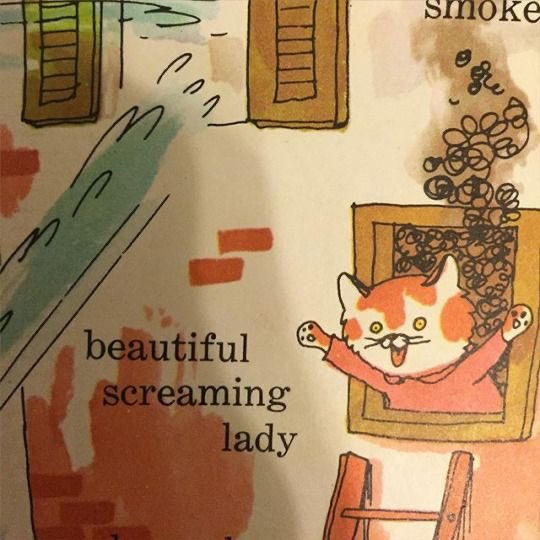

Now let's re-code the Chris variable. First thing's first, let's do up some pseudo-code. What are our steps?


1.   ?
2.   ?
3.   ?
4.   ?


In [ ]:
#Code goes here:


In [ ]:
# Look at it - did it work?

Great! Things are re-coded, but they're not numbers yet...

In [ ]:
# We can test this by trying to do a numerical thing with them:
super_data['NChris_Recoded'].mean()

In [ ]:
# Let's use 'super_data.dtypes' to check what we're dealing with here:
super_data.dtypes

#What to do with missing data 1: the case of the missing Chrises
Sometimes, NaN is the same as 0.

Sometimes it isn't!

Which is the case here?

In [ ]:
#If NaN = NaN, we can convert the data into a 'float' (a class of number that can accommodate NaNs):
super_data['NChris_Recoded'] = super_data['NChris_Recoded'].astype('float')

In [ ]:
#If NaN = 0, we have to re-code the NaNs as 0s and convert the data into a float or an integer:
super_data['NChris_Recoded'] = super_data['NChris_Recoded'].fillna(0) # this 'fills in' the NaNs with 0s
super_data['NChris_Recoded'] = super_data['NChris_Recoded'].astype(np.int64)# this converts the data type

In [ ]:
# Look at it!
super_data['NChris_Recoded']

In [ ]:
# Will it mean now?

# What do we want to explore now?
Let's play!

In [ ]:
#correlations:
r = super_data['Enjoyment'].corr(super_data['Silly'])
print(r)

In [ ]:
# Or we can get an entire matrix:
super_nums = super_data[["Enjoyment", "Fun","Silly","Tomatometer","Popcorn meter"]]
r = super_nums.corr()
print(r)

That's great, but we can also select columns of a particular data type. But what kinds of data do we have again?

In [ ]:
# dtypes will give us a list of the types of data we have:
super_data.dtypes

In [ ]:
# And we can make a new variable using only the numeric columns from the original data:
super_nums = super_data.select_dtypes(include=["float64","int64"])
super_nums.head()

In [ ]:
# and let's try it again:
r = super_nums.corr()
print(r)

In [ ]:
# Let's try a t-test
import scipy
from scipy.stats import ttest_ind

group1 = super_data[super_data['Studio']=='Marvel']
group2 = super_data[super_data['Studio']=='DC']

ttest_ind(group1['Popcorn meter'], group2['Popcorn meter'])

# End of day 1!
And that's it for today! Please give me your questions!